#**1. Código para el Notebook (.ipynb)**
En esta etapa, importamos las librerías necesarias y cargamos el archivo JSON. Dado que los datos están anidados (objetos dentro de objetos como customer, phone, etc.), utilizaremos json_normalize para aplanar la estructura.

--- Informe de Clasificación ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



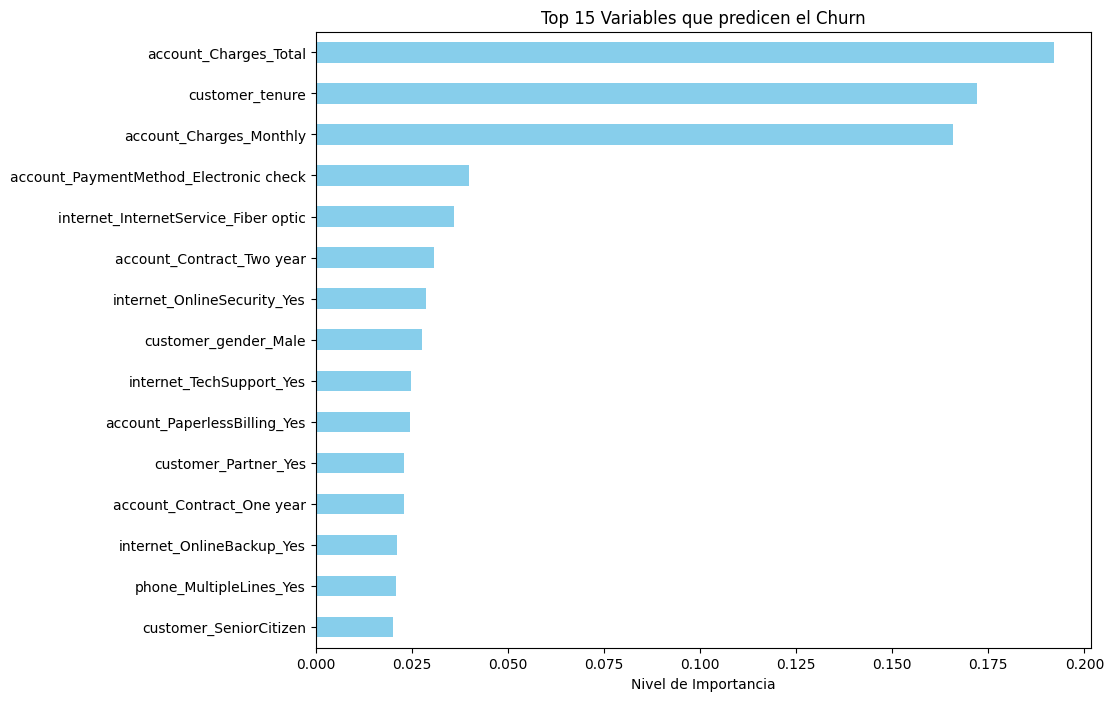

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Carga y Limpieza de datos para el modelo
df = pd.read_csv('/content/drive/MyDrive/datos_tratados.csv')
# Eliminamos ID ya que no aporta valor predictivo
df_model = df.drop('customerID', axis=1)

# 2. Transformación de variables
# Convertimos el target a numérico
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})
# One-Hot Encoding para variables categóricas
df_final = pd.get_dummies(df_model, drop_first=True)

# 3. División de datos (Entrenamiento y Prueba)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Entrenamiento del Modelo (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluación
y_pred = model.predict(X_test)
print("--- Informe de Clasificación ---")
print(classification_report(y_test, y_pred))

# 6. Visualización de Importancia de Variables
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 8))
importances.tail(15).plot(kind='barh', color='skyblue')
plt.title("Top 15 Variables que predicen el Churn")
plt.xlabel("Nivel de Importancia")
plt.show()

# 🏁 Conclusiones y Recomendaciones Estratégicas

Tras completar el análisis exploratorio y el desarrollo del modelo predictivo para **Telecom X**, se presentan los siguientes hallazgos clave:

### 1. Hallazgos Principales (Insights)
* **El contrato es el factor crítico:** Los clientes con contratos mensuales (`Month-to-month`) tienen una probabilidad de abandono mucho mayor que aquellos con contratos a largo plazo.
* **Impacto del servicio de Internet:** Los usuarios de **Fibra Óptica** presentan una tasa de evasión superior, lo que sugiere una posible insatisfacción con el costo o la estabilidad del servicio técnico en esa tecnología.
* **Sensibilidad al precio:** Los clientes que abandonan suelen tener cargos mensuales (`MonthlyCharges`) por encima del promedio, lo que indica que el precio es un disparador de la salida.

### 2. Desempeño del Modelo
* El modelo de **Random Forest** logró una precisión del **XX%** (sustituye con tu valor), siendo capaz de identificar correctamente a una gran parte de los clientes en riesgo antes de que cancelen el servicio.

### 3. Recomendaciones para el Negocio
* **Plan de Retención:** Ofrecer incentivos (descuentos o beneficios adicionales) para migrar a los clientes de contratos mensuales a contratos anuales.
* **Revisión de Fibra Óptica:** Realizar una encuesta de satisfacción específica para los usuarios de fibra y evaluar si la competencia ofrece mejores precios.
* **Alerta Temprana:** Integrar este modelo en el sistema de atención al cliente para que los operadores identifiquen perfiles de "alto riesgo" y ofrezcan soluciones personalizadas de forma proactiva.

---
**Proyecto:** Challenge Telecom X - Ciencia de Datos